In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
import ast

In [2]:
# Load the CSV
df = pd.read_csv("blackjack_uniform_data.csv")
display(df.head())
print(df.shape)

,player_sum,dealer_showing,usable_ace,action,reward,next_player_sum,next_dealer_showing,next_usable_ace,done
0,14,3,0,0,-1.0,14,3,0,1
1,10,8,0,0,1.0,10,8,0,1
2,12,3,0,1,0.0,15,3,0,0
3,15,3,0,0,-1.0,15,3,0,1
4,20,10,0,0,1.0,20,10,0,1


(69006, 9)


In [3]:
# Convert each row back to a state tuple
def row_to_state(row):
    return (int(row["player_sum"]),
            int(row["dealer_showing"]),
            bool(row["usable_ace"]))

def row_to_next_state(row):
    return (int(row["next_player_sum"]),
            int(row["next_dealer_showing"]),
            bool(row["next_usable_ace"]))

transitions = []
for _, row in df.iterrows():
    s = row_to_state(row)
    a = int(row["action"])
    r = float(row["reward"])
    s_next = row_to_next_state(row)
    done = bool(row["done"])
    transitions.append((s, a, r, s_next, done))

print("Number of transitions:", len(transitions))
print("First transition:", transitions[0])

Number of transitions: 69006
First transition: ((14, 3, False), 0, -1.0, (14, 3, False), True)


In [4]:
# Offline Q-learning, no environment interactions
def offline_q_learning(
    transitions,
    n_actions=2,
    n_epochs=50,
    alpha=0.05,
    gamma=1.0,
    shuffle=True
):
    Q = defaultdict(lambda: np.zeros(n_actions))
    history = []

    n = len(transitions)

    for epoch in range(n_epochs):
        if shuffle:
            idx = np.random.permutation(n)
        else:
            idx = np.arange(n)

        td_errors = []

        for i in idx:
            s, a, r, s_next, done = transitions[i]

            q_old = Q[s][a]

            if done:
                target = r
            else:
                target = r + gamma * np.max(Q[s_next])

            td_error = target - q_old
            Q[s][a] += alpha * td_error
            td_errors.append(abs(td_error))

        mean_td = np.mean(td_errors)
        history.append(mean_td)

        print(f"Epoch {epoch+1:3d}: mean |TD error| = {mean_td:.6f}")

    return Q, history

In [5]:
Q_offline, history = offline_q_learning(
    transitions,
    n_actions=2,
    n_epochs=100,
    alpha=0.05,
    gamma=1.0,
    shuffle=True
)

Epoch   1: mean |TD error| = 0.586318
Epoch   2: mean |TD error| = 0.574389
Epoch   3: mean |TD error| = 0.574314
Epoch   4: mean |TD error| = 0.574434
Epoch   5: mean |TD error| = 0.574060
Epoch   6: mean |TD error| = 0.573624
Epoch   7: mean |TD error| = 0.574018
Epoch   8: mean |TD error| = 0.574356
Epoch   9: mean |TD error| = 0.573696
Epoch  10: mean |TD error| = 0.573718
Epoch  11: mean |TD error| = 0.574209
Epoch  12: mean |TD error| = 0.573956
Epoch  13: mean |TD error| = 0.573891
Epoch  14: mean |TD error| = 0.574439
Epoch  15: mean |TD error| = 0.574101
Epoch  16: mean |TD error| = 0.574391
Epoch  17: mean |TD error| = 0.573860
Epoch  18: mean |TD error| = 0.573738
Epoch  19: mean |TD error| = 0.574293
Epoch  20: mean |TD error| = 0.572989
Epoch  21: mean |TD error| = 0.574478
Epoch  22: mean |TD error| = 0.573570
Epoch  23: mean |TD error| = 0.574146
Epoch  24: mean |TD error| = 0.574059
Epoch  25: mean |TD error| = 0.575071
Epoch  26: mean |TD error| = 0.573672
Epoch  27: m

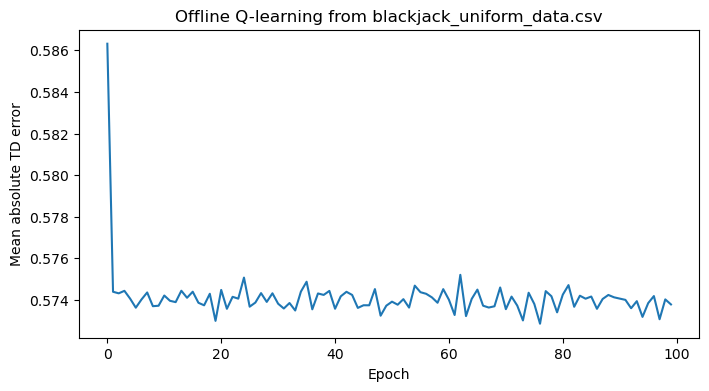

In [6]:
plt.figure(figsize=(8, 4))
plt.plot(history)
plt.xlabel("Epoch")
plt.ylabel("Mean absolute TD error")
plt.title("Offline Q-learning from blackjack_uniform_data.csv")
plt.show()

In [7]:
sample_states = [
    (20, 10, False),
    (13, 2, False),
    (18, 9, True),
    (12, 4, False),
]

for s in sample_states:
    action = int(np.argmax(Q_offline[s]))
    print(s, "->", "stick" if action == 0 else "hit", "| Q =", Q_offline[s])

(20, 10, False) -> stick | Q = [ 0.51551801 -0.79382888]
(13, 2, False) -> stick | Q = [-0.22323838 -0.27392716]
(18, 9, True) -> hit | Q = [-0.1284629   0.15645249]
(12, 4, False) -> hit | Q = [-0.60995218 -0.32921981]


In [8]:
# Evaluation, interact with the environment
import gymnasium as gym

env = gym.make("Blackjack-v1", natural=False, sab=False)

def evaluate_policy(env, Q, n_episodes=20000):
    total_reward = 0
    wins = losses = draws = 0

    for _ in range(n_episodes):
        state, info = env.reset()
        done = False

        while not done:
            action = int(np.argmax(Q[state]))
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            state = next_state

        total_reward += reward
        if reward > 0:
            wins += 1
        elif reward < 0:
            losses += 1
        else:
            draws += 1

    print("Average reward:", total_reward / n_episodes)
    print("Win rate:", wins / n_episodes)
    print("Loss rate:", losses / n_episodes)
    print("Draw rate:", draws / n_episodes)

evaluate_policy(env, Q_offline, n_episodes=20000)

Average reward: -0.06665
Win rate: 0.4228
Loss rate: 0.48945
Draw rate: 0.08775


In [11]:
import pickle

Q_dict = {k: v for k, v in Q_offline.items()}
with open("blackjack_offline_q.pkl", "wb") as f:
    pickle.dump(Q_dict, f)

print("Saved to blackjack_offline_q.pkl")

Saved to blackjack_offline_q.pkl
